# 🫁 AI Pneumonia Detection using Deep Learning
**Project Scope:** To develop a robust, high-recall Convolutional Neural Network (CNN) capable of detecting Pneumonia from pediatric Chest X-Rays.

## 1. Setup and GPU Configuration
To begin, I imported the necessary libraries for deep learning, data manipulation, and visualization. Because image classification is computationally heavy, I configured TensorFlow to utilize Kaggle's dual NVIDIA T4 GPUs. 

By wrapping the model in `tf.distribute.MirroredStrategy()`, I am able to parallelize the data processing and gradient calculations across both GPUs, cutting training time in half.

In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import DenseNet121

# Setup MirroredStrategy to use BOTH T4 GPUs simultaneously
strategy = tf.distribute.MirroredStrategy()
print(f"Number of GPUs being used: {strategy.num_replicas_in_sync}")

2026-05-03 14:06:05.958799: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777817166.346505      94 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777817166.461497      94 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777817167.477048      94 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777817167.477088      94 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777817167.477090      94 computation_placer.cc:177] computation placer alr

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of GPUs being used: 2


I0000 00:00:1777817209.960973      94 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777817209.966844      94 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## 2. Data Pipeline and Preprocessing
In this section, I constructed the data pipelines using TensorFlow's `image_dataset_from_directory` utility. 

**Key Preprocessing Steps:**
* **Image Resizing:** All X-rays are standardized to 224x224 pixels to match the input requirements of the DenseNet121 architecture.
* **RGB Conversion:** Although X-rays are naturally grayscale, the pre-trained DenseNet121 model was trained on ImageNet (which uses 3 color channels). Therefore, I loaded the images in `rgb` mode to satisfy the tensor shape requirements.
* **Performance Optimization:** I applied `tf.data.AUTOTUNE` to cache the datasets in memory and prefetch upcoming batches. This prevents I/O bottlenecking, ensuring the GPUs are never waiting on the CPU to read files from the disk.

In [2]:
# Exact paths to your dataset folders
base_dir = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Scale batch size for 2 GPUs (32 per GPU = 64 total)
BATCH_SIZE = 32 * strategy.num_replicas_in_sync 
IMG_SIZE = (224, 224)

# 1. Load Training Data (Changed to RGB for Transfer Learning)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    color_mode='rgb' # DenseNet requires RGB images
)

# 2. Load Validation Data
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    color_mode='rgb'
)

# 3. Load Testing Data
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    color_mode='rgb'
)

# Optimize datasets for faster pipeline performance
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


## 3. Exploratory Data Analysis (EDA)
Before designing the neural network, I conducted EDA to uncover underlying patterns and potential biases in the data.

### Class Distribution
Medical datasets are notoriously imbalanced, and this dataset is no exception. Below, I quantified the number of Normal vs. Pneumonia images. Understanding this imbalance is critical, as it dictates why we cannot rely solely on "Accuracy" as a metric later on.

/tmp/ipykernel_94/2622333470.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Normal', 'Pneumonia'], y=[normal_count, pneumonia_count], palette=['#2ecc71', '#e74c3c'])


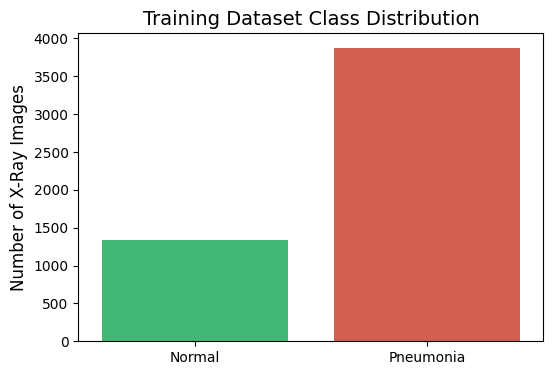

Total Normal X-rays: 1341
Total Pneumonia X-rays: 3875


In [3]:
# Count the number of images in each class in the training directory
normal_count = len(os.listdir(os.path.join(train_dir, 'NORMAL')))
pneumonia_count = len(os.listdir(os.path.join(train_dir, 'PNEUMONIA')))

# Plot the distribution
plt.figure(figsize=(6, 4))
sns.barplot(x=['Normal', 'Pneumonia'], y=[normal_count, pneumonia_count], palette=['#2ecc71', '#e74c3c'])
plt.title('Training Dataset Class Distribution', fontsize=14)
plt.ylabel('Number of X-Ray Images', fontsize=12)
plt.show()

print(f"Total Normal X-rays: {normal_count}")
print(f"Total Pneumonia X-rays: {pneumonia_count}")

### Visualizing the Data
Next, I visualized a sample grid of X-rays. From a medical standpoint, Pneumonia presents as "opacities" or cloudy white infiltrates within the lung cavities. Healthy lungs appear darker because X-rays pass easily through the air. My goal is to train the CNN to identify these faint cloudy textures automatically.

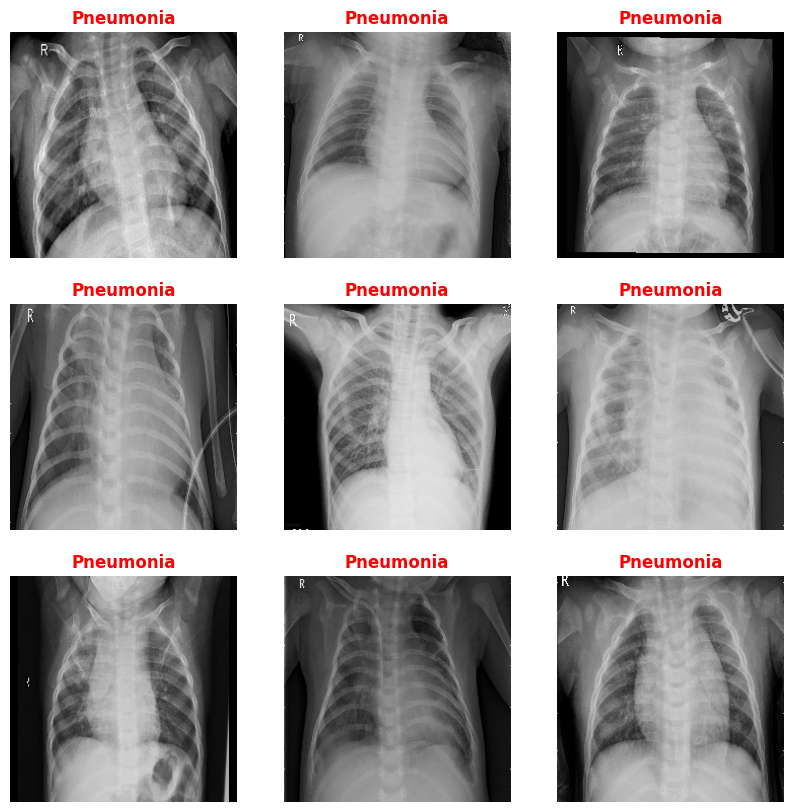

In [4]:
plt.figure(figsize=(10, 10))

# Take one batch from the training dataset
for images, labels in train_dataset.take(1):
    for i in range(9): # Display 9 images
        ax = plt.subplot(3, 3, i + 1)
        
        # Convert pixel values to integer for clean plotting
        plt.imshow(images[i].numpy().astype("uint8")) 
        
        # Interpret labels: 1 = Pneumonia, 0 = Normal
        diagnosis = "Pneumonia" if int(labels[i]) == 1 else "Normal"
        color = 'red' if diagnosis == "Pneumonia" else 'green'
        
        plt.title(diagnosis, color=color, fontweight='bold')
        plt.axis("off")
    break # Only need one batch
plt.show()

## 4. Transfer Learning Architecture (DenseNet121)
To achieve clinical-grade accuracy, I utilized **Transfer Learning** via the DenseNet121 architecture. 

1. **The Base Model:** I loaded DenseNet121 pre-trained on the ImageNet dataset. Because it has already "learned" how to detect edges, textures, and shapes from 1.4 million images, I froze these base layers to preserve their structural weights.
2. **The Custom Head:** I appended a `GlobalAveragePooling2D` layer to flatten the feature maps, followed by a `Dense` layer and `Dropout` (to mitigate overfitting). 
3. **The Output:** The final layer uses a Sigmoid activation function to yield a binary probability: `0` (Normal) to `1` (Pneumonia).

In [5]:
def create_transfer_model():
    # Load Pre-trained DenseNet121 (without the final classification layer)
    base_model = DenseNet121(
        weights='imagenet',       
        include_top=False,        
        input_shape=(224, 224, 3) 
    )
    
    # Freeze the base model to preserve its pre-trained knowledge
    base_model.trainable = False 

    model = models.Sequential([
        # Input and Data Augmentation
        layers.InputLayer(input_shape=(224, 224, 3)),
        layers.Rescaling(1./255),
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        
        # Add the Pre-trained DenseNet121 Base
        base_model,
        
        # Custom Classification Head
        layers.GlobalAveragePooling2D(), 
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5), # Prevent overfitting
        layers.Dense(1, activation='sigmoid') # Normal vs Pneumonia
    ])
    
    # Compile with gradient clipping (clipnorm=1.0) to prevent 'nan' loss
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
    )
    return model

# Create model inside GPU strategy scope
with strategy.scope():
    tl_model = create_transfer_model()

tl_model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,161 (27.85 MB)

 Trainable params: 262,657 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

## 5. Model Training & Callbacks
To optimize the training loop and prevent the model from memorizing the data, I implemented two dynamic callbacks:
* **EarlyStopping:** Monitors the validation loss. If the loss fails to improve for 5 consecutive epochs, training halts early and the best weights are restored.
* **ReduceLROnPlateau:** Gradually reduces the Adam learning rate when the model plateaus, allowing the optimizer to make finer adjustments as it approaches the global minimum.

In [6]:
# Callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

lr_reduction = callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    patience=3, 
    factor=0.3, 
    min_lr=0.000001
)

# Train the Transfer Learning model
EPOCHS = 20

history = tl_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping, lr_reduction]
)

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

I0000 00:00:1777817377.294464     141 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777817377.782314     140 cuda_dnn.cc:529] Loaded cuDNN version 91002


82/82 ━━━━━━━━━━━━━━━━━━━━ 54s 390ms/step - accuracy: 0.7228 - loss: 0.5748 - precision: 0.7781 - recall: 0.8763 - val_accuracy: 0.6875 - val_loss: 0.5032 - val_precision: 0.6154 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 143ms/step - accuracy: 0.8676 - loss: 0.3045 - precision: 0.8872 - recall: 0.9424 - val_accuracy: 0.6875 - val_loss: 0.5530 - val_precision: 0.6154 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 148ms/step - accuracy: 0.9029 - loss: 0.2419 - precision: 0.9201 - recall: 0.9523 - val_accuracy: 0.6875 - val_loss: 0.4782 - val_precision: 0.6154 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 150ms/step - accuracy: 0.9193 - loss: 0.2130 - precision: 0.9419 - recall: 0.9506 - val_accuracy: 0.6875 - val_loss: 0.4493 - val_precision: 0.6154 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 5/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 147ms/step - 

## 6. Visualizing Training Performance
I plotted the model's accuracy and loss over time. A healthy training curve will show the training and validation lines converging closely together. A widening gap between the two would indicate overfitting.

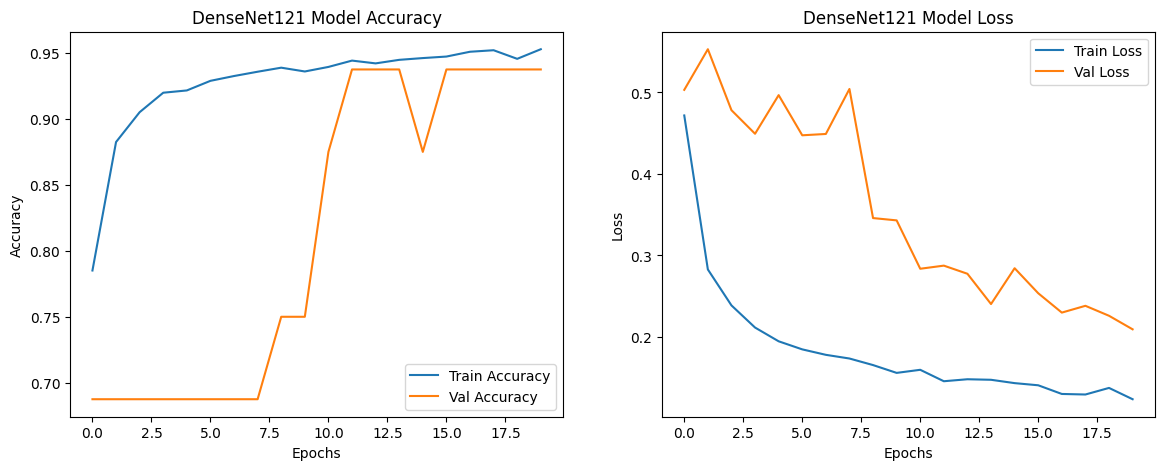

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
ax[0].plot(history.history['accuracy'], label='Train Accuracy')
ax[0].plot(history.history['val_accuracy'], label='Val Accuracy')
ax[0].set_title('DenseNet121 Model Accuracy')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

# Plot Loss
ax[1].plot(history.history['loss'], label='Train Loss')
ax[1].plot(history.history['val_loss'], label='Val Loss')
ax[1].set_title('DenseNet121 Model Loss')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.show()

## 7. Final Evaluation & Medical Viability
In a clinical setting, an AI diagnostic tool must be evaluated beyond basic accuracy. 
* A **False Negative** means sending a sick patient home, which can be fatal. 
* A **False Positive** means ordering a secondary test for a healthy patient, which is merely an inconvenience.

Therefore, the most critical metric for this model is **Recall (Sensitivity)**. Below, I generated a Confusion Matrix and a Detailed Classification Report to verify that the model correctly catches the vast majority of true Pneumonia cases.

Evaluating on Test Dataset...
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 374ms/step - accuracy: 0.8232 - loss: 0.4422 - precision: 0.5260 - recall: 0.6507 


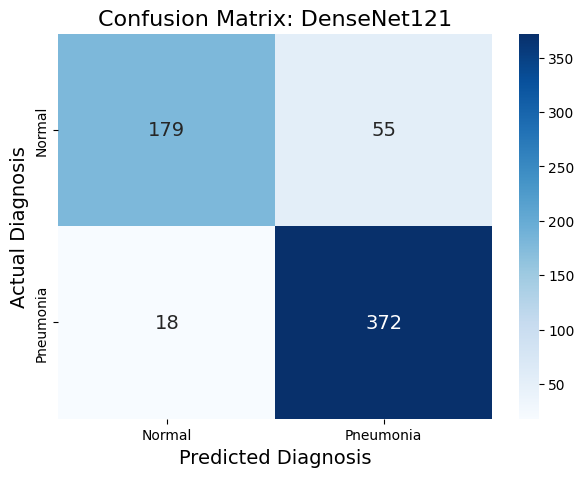


--- Detailed Classification Report ---
              precision    recall  f1-score   support

      Normal       0.91      0.76      0.83       234
   Pneumonia       0.87      0.95      0.91       390

    accuracy                           0.88       624
   macro avg       0.89      0.86      0.87       624
weighted avg       0.89      0.88      0.88       624



In [8]:
# 1. Standard Evaluation
print("Evaluating on Test Dataset...")
test_loss, test_accuracy, test_precision, test_recall = tl_model.evaluate(test_dataset)

# 2. Generate Predictions for Confusion Matrix
y_true = []
y_pred_probs = []

for images, labels in test_dataset:
    y_true.extend(labels.numpy())
    preds = tl_model.predict(images, verbose=0)
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred = (np.array(y_pred_probs) > 0.5).astype(int)

# 3. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Pneumonia'], 
            yticklabels=['Normal', 'Pneumonia'],
            annot_kws={"size": 14})
plt.title('Confusion Matrix: DenseNet121', fontsize=16)
plt.ylabel('Actual Diagnosis', fontsize=14)
plt.xlabel('Predicted Diagnosis', fontsize=14)
plt.show()

# 4. Detailed Classification Report
print("\n--- Detailed Classification Report ---")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

## 8. Exporting the Model for MLOps Deployment
With the model successfully trained and exhibiting high recall, I serialized the weights into a `.keras` file. 

This file will be deployed into a Streamlit web application. To solve the "Black Box" nature of neural networks, the web app will implement **Grad-CAM (Explainable AI)**, overlaying heatmaps onto the uploaded X-rays to visually prove to doctors exactly where the model detected the lung infection.

In [12]:
tl_model.save("transfer_learning_model.keras")